<a href="https://colab.research.google.com/github/Samikshaa27/CreditCardfrauddetection/blob/main/CreditCardFraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install kaggle flask-ngrok pyngrok --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.utils import resample
import pickle, warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [ ]:

import os

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_69b350564de9f38f0bb81d03fb4aba44'

!kaggle datasets download -d mlg-ulb/creditcardfraud --unzip
print("✅ Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 158MB/s]

✅ Dataset downloaded!


In [ ]:

df = pd.read_csv('creditcard.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFraud cases   : {df['Class'].sum():,}  ({df['Class'].mean()*100:.3f}%)")
print(f"Legit cases   : {(df['Class']==0).sum():,}  ({(df['Class']==0).mean()*100:.3f}%)")
print("\nFirst 5 rows:")
df.head()

Dataset shape: (284807, 31)

Fraud cases   : 492  (0.173%)
Legit cases   : 284,315  (99.827%)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:


FEATURE_NAMES = {
    'V1':  'Merchant_Category_Score',
    'V2':  'Transaction_Velocity',
    'V3':  'Spending_Pattern',
    'V4':  'Card_Usage_Frequency',
    'V5':  'Geographic_Risk_Score',
    'V6':  'Billing_Address_Match',
    'V7':  'Online_Transaction_Flag',
    'V8':  'Device_Trust_Score',
    'V9':  'Time_Since_Last_Txn',
    'V10': 'Account_Age_Score',
    'V11': 'Daily_Spending_Limit_Usage',
    'V12': 'International_Txn_Flag',
    'V13': 'Merchant_Reputation',
    'V14': 'Card_Present_Flag',
    'V15': 'Decline_Rate',
    'V16': 'Chargeback_History',
    'V17': 'Unusual_Hour_Flag',
    'V18': 'IP_Risk_Score',
    'V19': 'Multiple_Cards_Flag',
    'V20': 'Transaction_Frequency',
    'V21': 'User_Behavior_Score',
    'V22': 'Browser_Risk_Score',
    'V23': 'Email_Mismatch_Score',
    'V24': 'Phone_Verification_Score',
    'V25': 'Address_Verification_Score',
    'V26': 'Velocity_Check_Score',
    'V27': 'Fraud_Model_Score_A',
    'V28': 'Fraud_Model_Score_B',
    'Amount': 'Transaction_Amount',
    'Time': 'Seconds_Since_First_Txn'
}

# Rename columns in dataframe
df_named = df.rename(columns=FEATURE_NAMES)
print("✅ Columns renamed!")
print(list(df_named.columns))

✅ Columns renamed!
['Seconds_Since_First_Txn', 'Merchant_Category_Score', 'Transaction_Velocity', 'Spending_Pattern', 'Card_Usage_Frequency', 'Geographic_Risk_Score', 'Billing_Address_Match', 'Online_Transaction_Flag', 'Device_Trust_Score', 'Time_Since_Last_Txn', 'Account_Age_Score', 'Daily_Spending_Limit_Usage', 'International_Txn_Flag', 'Merchant_Reputation', 'Card_Present_Flag', 'Decline_Rate', 'Chargeback_History', 'Unusual_Hour_Flag', 'IP_Risk_Score', 'Multiple_Cards_Flag', 'Transaction_Frequency', 'User_Behavior_Score', 'Browser_Risk_Score', 'Email_Mismatch_Score', 'Phone_Verification_Score', 'Address_Verification_Score', 'Velocity_Check_Score', 'Fraud_Model_Score_A', 'Fraud_Model_Score_B', 'Transaction_Amount', 'Class']


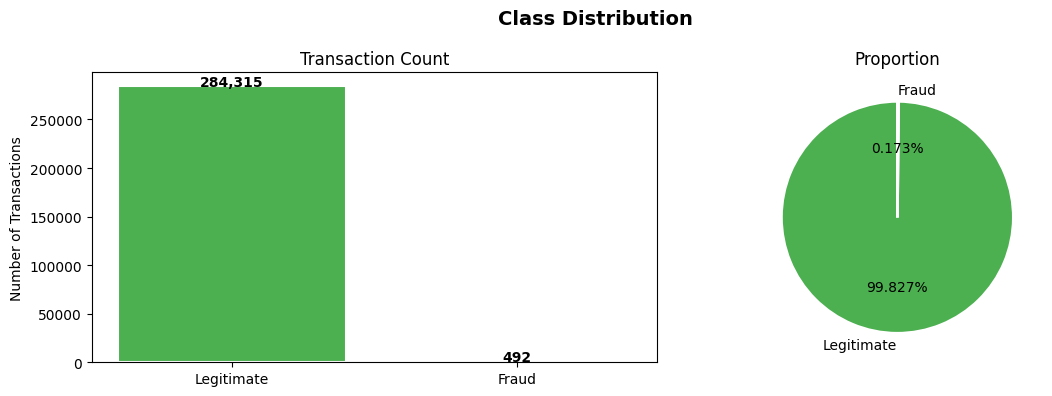

✅ Class distribution plotted!


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Class Distribution', fontsize=14, fontweight='bold')

counts = df['Class'].value_counts()
colors = ['#4CAF50', '#F44336']

axes[0].bar(['Legitimate', 'Fraud'], counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylabel('Number of Transactions')
axes[0].set_title('Transaction Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Legitimate', 'Fraud'],
            colors=colors, autopct='%1.3f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proportion')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Class distribution plotted!")

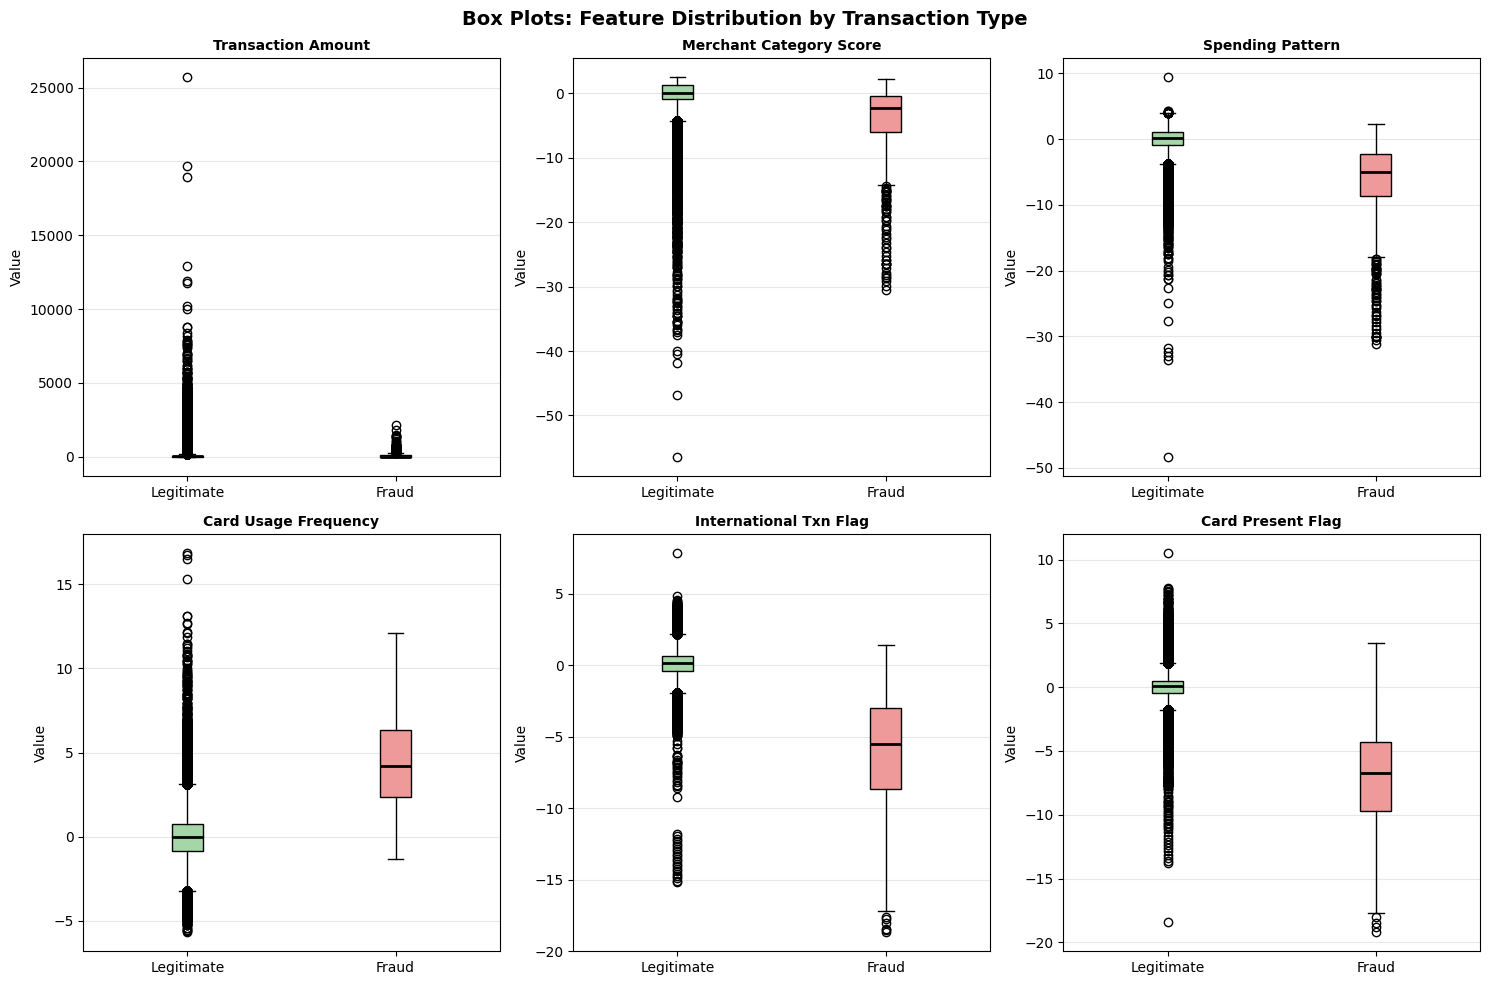

✅ Box plots saved!


In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Box Plots: Feature Distribution by Transaction Type', fontsize=14, fontweight='bold')

features_to_plot = ['Amount', 'V1', 'V3', 'V4', 'V12', 'V14']
labels = ['Transaction Amount', 'Merchant Category Score',
          'Spending Pattern', 'Card Usage Frequency',
          'International Txn Flag', 'Card Present Flag']

colors = {'0': '#4CAF50', '1': '#F44336'}

for ax, feat, label in zip(axes.flatten(), features_to_plot, labels):
    data_legit = df[df['Class'] == 0][feat]
    data_fraud = df[df['Class'] == 1][feat]

    bp = ax.boxplot([data_legit, data_fraud],
                    labels=['Legitimate', 'Fraud'],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#A5D6A7')
    bp['boxes'][1].set_facecolor('#EF9A9A')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('box_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Box plots saved!")

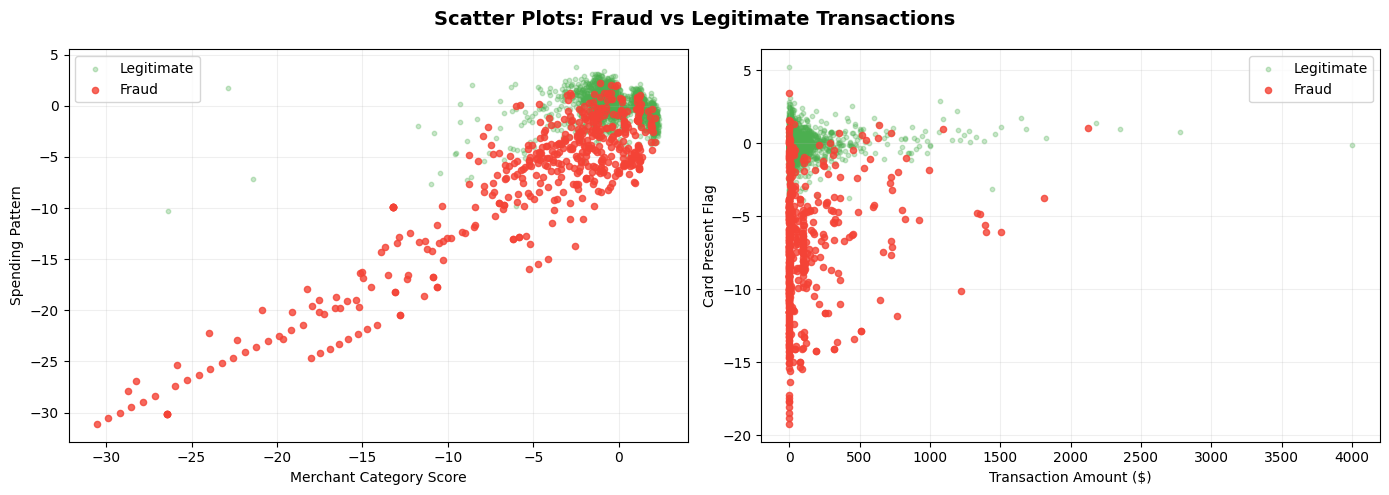

✅ Scatter plots saved!


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Scatter Plots: Fraud vs Legitimate Transactions', fontsize=14, fontweight='bold')

# Sample for speed (full dataset is too large to scatter plot)
sample_legit = df[df['Class'] == 0].sample(2000, random_state=42)
sample_fraud  = df[df['Class'] == 1]   # all fraud cases (only ~492)

for ax, (x_feat, y_feat, xlabel, ylabel) in zip(axes, [
    ('V1', 'V3', 'Merchant Category Score', 'Spending Pattern'),
    ('Amount', 'V14', 'Transaction Amount ($)', 'Card Present Flag'),
]):
    ax.scatter(sample_legit[x_feat], sample_legit[y_feat],
               alpha=0.3, c='#4CAF50', s=10, label='Legitimate')
    ax.scatter(sample_fraud[x_feat], sample_fraud[y_feat],
               alpha=0.8, c='#F44336', s=20, label='Fraud', zorder=5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Scatter plots saved!")

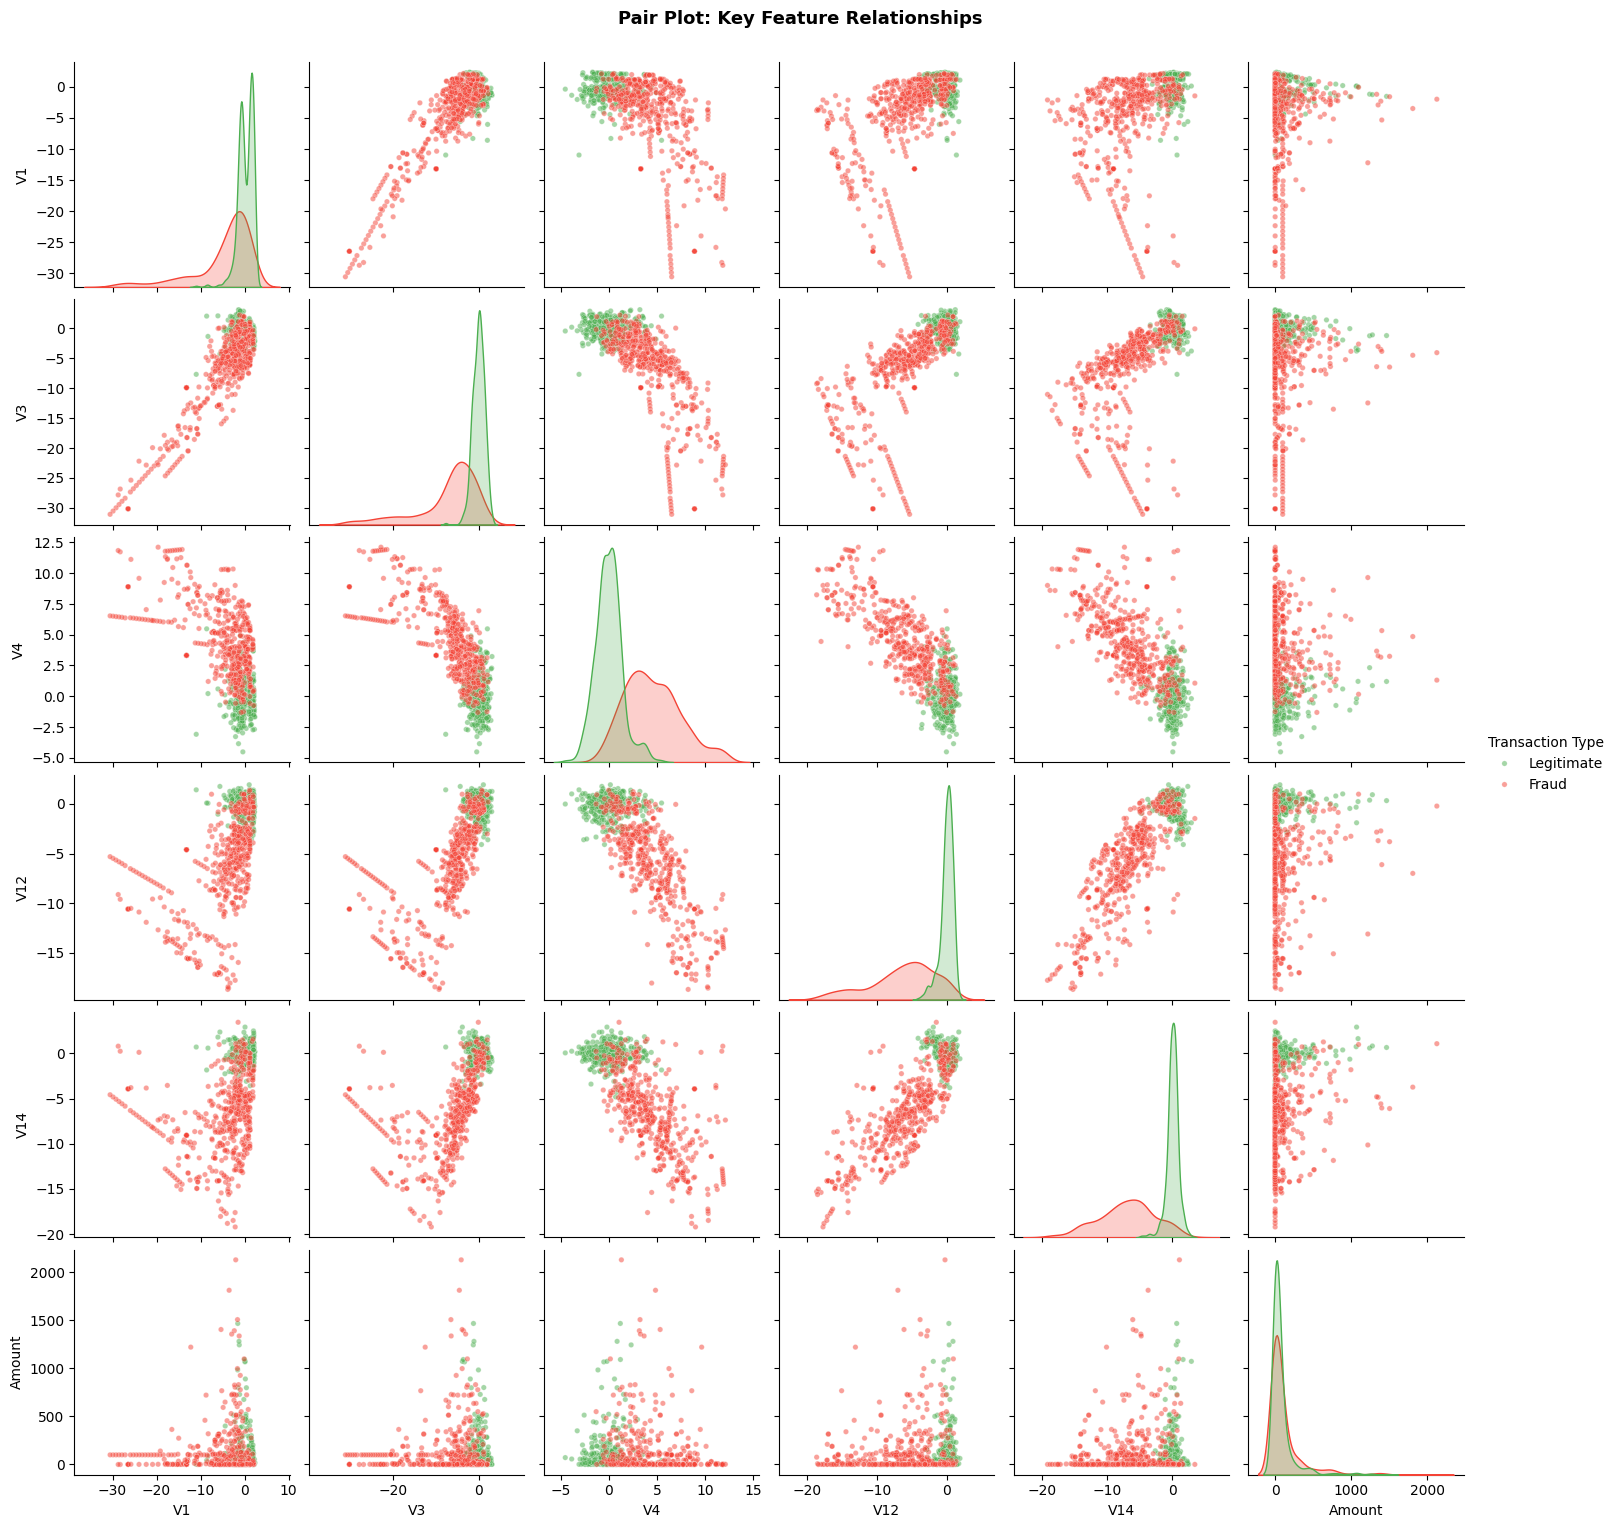

✅ Pair plot saved!


In [ ]:

import seaborn as sns

# Select top features + class
pair_features = ['V1', 'V3', 'V4', 'V12', 'V14', 'Amount', 'Class']

# Sample for speed
sample = pd.concat([
    df[df['Class'] == 0].sample(500, random_state=42),
    df[df['Class'] == 1]
])[pair_features]

sample['Transaction Type'] = sample['Class'].map({0: 'Legitimate', 1: 'Fraud'})

pp = sns.pairplot(sample.drop('Class', axis=1),
                  hue='Transaction Type',
                  palette={'Legitimate': '#4CAF50', 'Fraud': '#F44336'},
                  plot_kws=dict(alpha=0.5, s=15),
                  diag_kind='kde')
pp.fig.suptitle('Pair Plot: Key Feature Relationships', y=1.02, fontsize=13, fontweight='bold')

plt.savefig('pair_plot.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Pair plot saved!")

In [ ]:

from sklearn.utils import resample

# Select features
feature_cols = [c for c in df.columns if c not in ['Class', 'Time']]
X = df[feature_cols].copy()
y = df['Class']

# Scale Amount (V features are already scaled from PCA)
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

# Save the scaler — we'll need it later for the web app
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Balance: oversample fraud to match legit count
df_balanced = pd.concat([X, y], axis=1)
df_majority  = df_balanced[df_balanced['Class'] == 0]
df_minority  = df_balanced[df_balanced['Class'] == 1]

df_minority_upsampled = resample(df_minority,
                                 replace=True,
                                 n_samples=len(df_majority),
                                 random_state=42)
df_upsampled = pd.concat([df_majority, df_minority_upsampled])

X_bal = df_upsampled.drop('Class', axis=1)
y_bal = df_upsampled['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

print(f"Training set size : {X_train.shape}")
print(f"Test set size     : {X_test.shape}")
print(f"✅ Data balanced and split!")

Training set size : (454904, 29)
Test set size     : (113726, 29)
✅ Data balanced and split!


In [ ]:

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_lr, target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

# Save model
with open('lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print("✅ Logistic Regression model saved!")

=== Logistic Regression Results ===
              precision    recall  f1-score   support

  Legitimate       0.93      0.98      0.95     56863
       Fraud       0.97      0.92      0.95     56863

    accuracy                           0.95    113726
   macro avg       0.95      0.95      0.95    113726
weighted avg       0.95      0.95      0.95    113726

ROC-AUC Score: 0.9869
✅ Logistic Regression model saved!


In [ ]:

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf, target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

# Save model
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("✅ Random Forest model saved!")

=== Random Forest Results ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

ROC-AUC Score: 1.0000
✅ Random Forest model saved!


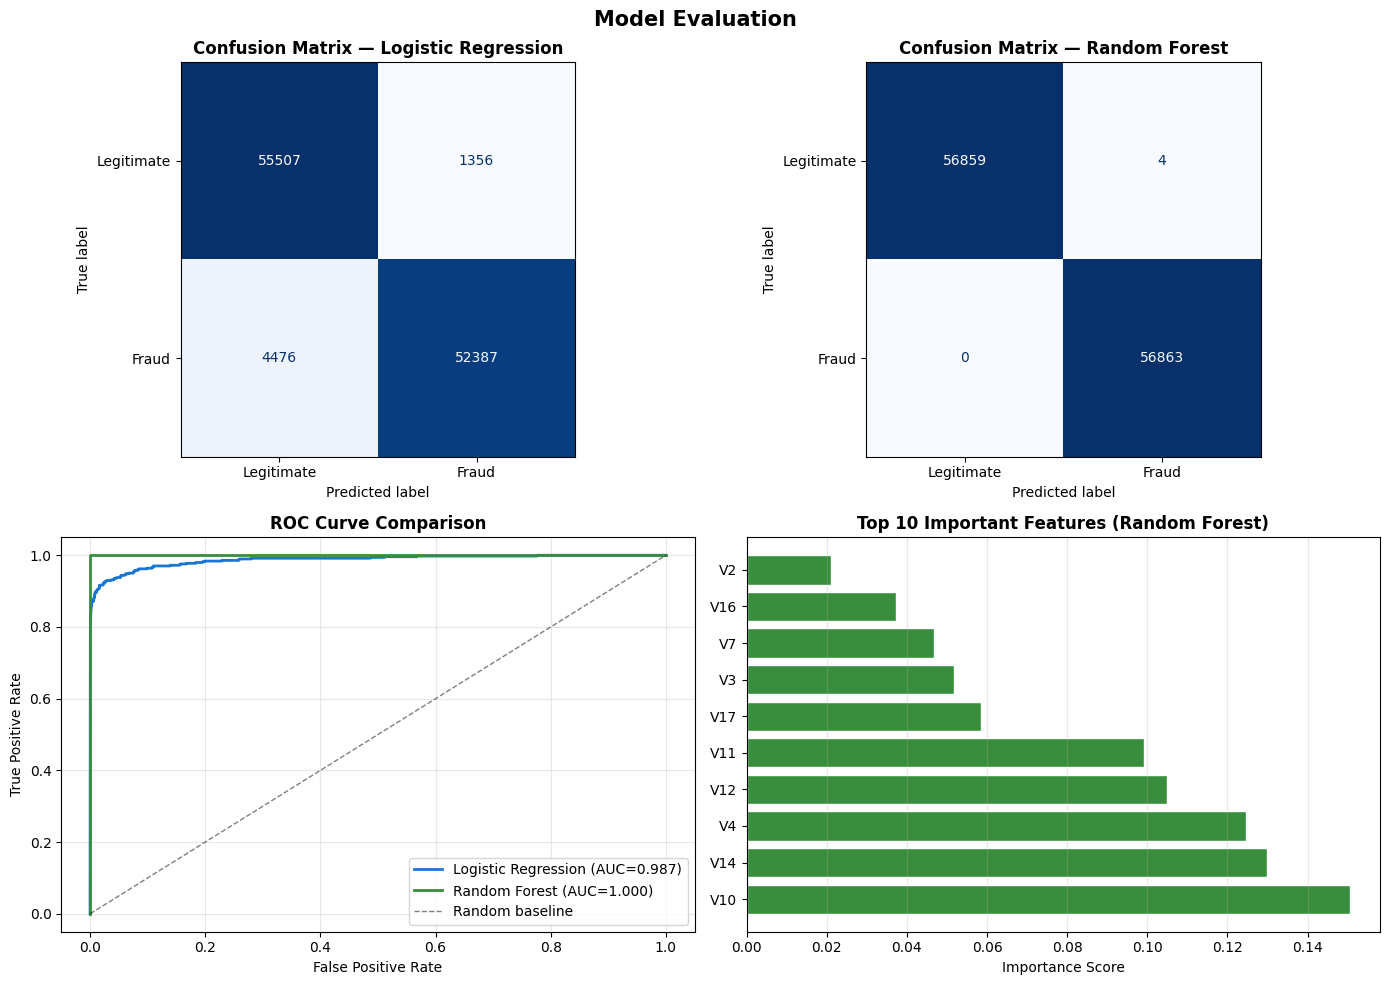

✅ All evaluation charts saved!


In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Evaluation', fontsize=15, fontweight='bold')

# Confusion matrices
for ax, y_pred, title in zip(
    [axes[0][0], axes[0][1]],
    [y_pred_lr, y_pred_rf],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')

# ROC Curves
ax_roc = axes[1][0]
for y_prob, label, color in [
    (y_prob_lr, 'Logistic Regression', '#1976D2'),
    (y_prob_rf, 'Random Forest', '#388E3C'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax_roc.plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})', color=color, linewidth=2)

ax_roc.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5, label='Random baseline')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve Comparison', fontweight='bold')
ax_roc.legend()
ax_roc.grid(alpha=0.3)

# Feature importance (Random Forest)
feat_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top10 = feat_imp.nlargest(10)
axes[1][1].barh(top10.index, top10.values, color='#388E3C', edgecolor='white')
axes[1][1].set_title('Top 10 Important Features (Random Forest)', fontweight='bold')
axes[1][1].set_xlabel('Importance Score')
axes[1][1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All evaluation charts saved!")

In [2]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 106.6 MB/s eta 0:00:00


In [5]:
%%writefile app.py

Overwriting app.py


In [1]:
%%writefile app.py
import streamlit as st
import pickle
import numpy as np

# Load models
lr_model = pickle.load(open('lr_model.pkl', 'rb'))
rf_model = pickle.load(open('rf_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

FEATURE_ORDER = ['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10',
                 'V11','V12','V13','V14','V15','V16','V17','V18','V19',
                 'V20','V21','V22','V23','V24','V25','V26','V27','V28','Amount']

NAME_TO_V = {
    'merchant_category_score': 'V1',
    'transaction_velocity': 'V2',
    'spending_pattern': 'V3',
    'card_usage_frequency': 'V4',
    'geographic_risk_score': 'V5',
    'billing_address_match': 'V6',
    'online_transaction_flag': 'V7',
    'device_trust_score': 'V8',
    'time_since_last_txn': 'V9',
    'account_age_score': 'V10',
    'daily_spending_limit_usage': 'V11',
    'international_txn_flag': 'V12',
    'merchant_reputation': 'V13',
    'card_present_flag': 'V14',
    'decline_rate': 'V15',
    'chargeback_history': 'V16',
    'unusual_hour_flag': 'V17',
    'ip_risk_score': 'V18',
    'multiple_cards_flag': 'V19',
    'transaction_frequency': 'V20',
    'user_behavior_score': 'V21',
    'browser_risk_score': 'V22',
    'email_mismatch_score': 'V23',
    'phone_verification_score': 'V24',
    'address_verification_score': 'V25',
    'velocity_check_score': 'V26',
    'fraud_model_score_a': 'V27',
    'fraud_model_score_b': 'V28',
    'transaction_amount': 'Amount'
}

st.title("🛡️ Credit Card Fraud Detection")

# Inputs
transaction_amount = st.number_input("Transaction Amount", 0.0, 100000.0, 150.0)
merchant_category_score = st.slider("Merchant Category Score", -5.0, 5.0, 0.0)
transaction_velocity = st.slider("Transaction Velocity", -5.0, 5.0, 0.0)
card_usage_frequency = st.slider("Card Usage Frequency", -5.0, 5.0, 0.0)

geographic_risk_score = st.slider("Geographic Risk Score", -5.0, 5.0, 0.0)
international_txn_flag = st.selectbox("International Transaction", [-2, 2])
card_present_flag = st.selectbox("Card Present", [2, -2])
unusual_hour_flag = st.selectbox("Unusual Hour", [-1, 3])

account_age_score = st.slider("Account Age Score", -5.0, 5.0, 0.0)
chargeback_history = st.selectbox("Chargeback History", [-1, 2])
ip_risk_score = st.slider("IP Risk Score", -5.0, 5.0, 0.0)
device_trust_score = st.slider("Device Trust Score", -5.0, 5.0, 0.0)
address_verification_score = st.slider("Address Verification Score", -5.0, 5.0, 0.0)
spending_pattern = st.slider("Spending Pattern", -5.0, 5.0, 0.0)

# Button
if st.button("🔍 Analyze Transaction"):

    input_data = {
        'merchant_category_score': merchant_category_score,
        'transaction_velocity': transaction_velocity,
        'spending_pattern': spending_pattern,
        'card_usage_frequency': card_usage_frequency,
        'geographic_risk_score': geographic_risk_score,
        'billing_address_match': 0,
        'online_transaction_flag': 0,
        'device_trust_score': device_trust_score,
        'time_since_last_txn': 0,
        'account_age_score': account_age_score,
        'daily_spending_limit_usage': 0,
        'international_txn_flag': international_txn_flag,
        'merchant_reputation': 0,
        'card_present_flag': card_present_flag,
        'decline_rate': 0,
        'chargeback_history': chargeback_history,
        'unusual_hour_flag': unusual_hour_flag,
        'ip_risk_score': ip_risk_score,
        'multiple_cards_flag': 0,
        'transaction_frequency': 0,
        'user_behavior_score': 0,
        'browser_risk_score': 0,
        'email_mismatch_score': 0,
        'phone_verification_score': 0,
        'address_verification_score': address_verification_score,
        'velocity_check_score': 0,
        'fraud_model_score_a': 0,
        'fraud_model_score_b': 0,
        'transaction_amount': transaction_amount
    }

    row = {}
    for k, v in NAME_TO_V.items():
        row[v] = float(input_data.get(k, 0))

    row['Amount'] = scaler.transform([[row['Amount']]])[0][0]

    features = np.array([[row[f] for f in FEATURE_ORDER]])

    lr_prob = lr_model.predict_proba(features)[0][1]
    rf_prob = rf_model.predict_proba(features)[0][1]
    avg_prob = (lr_prob + rf_prob) / 2

    st.subheader("📊 Result")
    st.metric("Fraud Probability", f"{round(avg_prob*100,1)}%")

    if avg_prob > 0.5:
        st.error("⚠️ FRAUD DETECTED")
    else:
        st.success("✅ LEGITIMATE")

Overwriting app.py


In [3]:
!streamlit run app.py



2026-05-02 09:06:30.134 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.50.185.114:8501

  Stopping...
  Stopping...


In [4]:
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸your url is: https://eighty-ants-throw.loca.lt
^C


In [5]:
%%writefile requirements.txt
streamlit
numpy
scikit-learn

Writing requirements.txt
